In [1]:
import argparse
import glob
import logging
import os
import sys
import cv2
import time
import torch
import numpy as np
import matplotlib.pyplot as plt

from tqdm import tqdm
from v2ecore.slomo_mem import SuperSloMoMem
from v2ecore.emulator import EventEmulator
from v2ecore.v2e_utils import all_images, read_image

In [2]:
input_folder = "data/scene0711_00/color"

image_files = []
image_files.extend(glob.glob(os.path.join(input_folder, "*.jpg")))

image_files = sorted(image_files, key=lambda x: int(os.path.splitext(os.path.basename(x))[0]))

src_num_frames = len(image_files)
src_fps = 30

print(f"Found {src_num_frames} frames at {src_fps} fps.")

Found 3361 frames at 30 fps.


In [3]:
frames = []
output_width, output_height = 640, 480

for image_file in tqdm(image_files, desc="RGB2GRAY"):
    frame = cv2.imread(image_file)
    frame = cv2.resize(frame, (output_width, output_height), interpolation=cv2.INTER_AREA)

    if frame.ndim == 3:
        frame = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)

    frames.append(frame)

RGB2GRAY: 100%|██████████| 3361/3361 [00:43<00:00, 76.80it/s]


In [5]:
frames = np.array(frames)[:120]

In [6]:
slomo = SuperSloMoMem(model_path="input/SuperSloMo39.ckpt", upsampling_factor=5, batch_size=16)

In [7]:
out_frames, interp_times = slomo.interpolate(frames)

slomo-interp: 100%|██████████| 8/8 [00:17<00:00,  2.20s/batch]


In [9]:
last_frame = np.expand_dims(frames[-1], axis=0)
out_frames = np.concatenate([out_frames, last_frame], axis=0)

In [10]:
interp_times = np.concatenate([interp_times, [interp_times[-1] + 1 / 5]], axis=0)

In [12]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'

In [46]:
del emulator

emulator = EventEmulator(
    pos_thres=0.2,
    neg_thres=0.2,
    sigma_thres=0.03,
    cutoff_hz=0,
    leak_rate_hz=0.1,
    shot_noise_rate_hz=0.001,
    refractory_period_s=0.0005,
    seed=0,
    output_width=output_width,
    output_height=output_height,
    device=device
)

cannot get screen size for window placement: No enumerators available


In [14]:
n_frames = out_frames.shape[0]

In [15]:
n_frames

596

In [ ]:
def to_event_frame(events, height, width):
    event_frame = np.zeros((height, width, 3), dtype=np.uint8)
    ts = events[:, 0]
    xs = events[:, 2].astype(int)
    ys = events[:, 1].astype(int)
    pols = events[:, 3].astype(int) + 1
    
    # np.add.at(event_frame, (ys, xs), pols)
    event_frame[xs, ys, pols] = 255
    return event_frame

def create_voxel_grid(events, n_bins=5, width=640, height=480):
    dts = n_bins * (events["t"] - events["t"][0]) / (events["t"].max() - events["t"].min())
    bin_indices = dts.astype(int)
    bin_indices = np.clip(bin_indices, 0, n_bins - 1)

    voxel_grid = np.zeros((n_bins, height, width), dtype=np.float32)
    np.add.at(voxel_grid, (bin_indices, events["y"], events["x"]), 2 * events["pol"] - 1)
    return voxel_grid

In [38]:
def to_voxel_grid_slice(events, height, width):
    voxel_grid = np.zeros((1, height, width), dtype=np.float32)
    if events is None or events.shape[0] == 0:
        return voxel_grid
    
    np.add.at(voxel_grid, (0, events[:, 2].astype(int), events[:, 1].astype(int)), events[:, 3])
    return voxel_grid

In [47]:
# event_buffer = np.empty((0, 4), dtype=np.float32)
voxel_grid = np.zeros((5, output_height, output_width), dtype=np.float32)

emulator.reset()

with tqdm(total=n_frames, desc='dvs', unit='fr') as pbar:
    with torch.no_grad():
        for i in range(n_frames):
            events = emulator.generate_events(out_frames[i], interp_times[i])
            pbar.update(1)

            if i == 0:
                continue
            
            # voxel_grid = to_voxel_grid_slice(events, output_height, output_width)
            
            if events is not None and events.shape[0] > 0:
                np.add.at(voxel_grid, ((i - 1) % 5, events[:, 2].astype(int), events[:, 1].astype(int)), events[:, 3])

            if i % 5 == 0:
                np.savez_compressed(f"data/dump/voxel_grid_{i}.npz", voxel_grid=voxel_grid)
                voxel_grid = np.zeros((5, output_height, output_width), dtype=np.float32)

dvs: 100%|██████████| 596/596 [00:19<00:00, 30.31fr/s]


In [104]:
# write a video

video = cv2.VideoWriter('event.avi', cv2.VideoWriter_fourcc(*'XVID'), src_fps, (output_width, output_height), isColor=True)
for event_frame in event_frames:
    video.write(event_frame)
video.release()

In [29]:
events = event_frames[0]

In [30]:
events[:, 1].max(), events[:, 2].max()

(np.float32(639.0), np.float32(479.0))

In [49]:
vg = np.load("data/dump/voxel_grid_5.npz")["voxel_grid"]

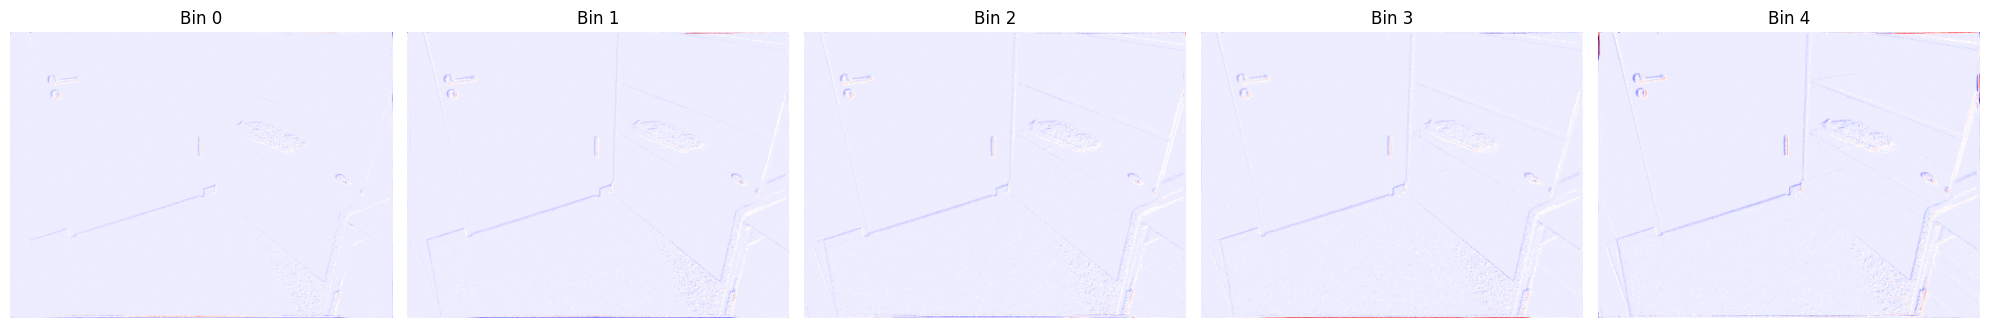

In [50]:
fig, axes = plt.subplots(1, vg.shape[0], figsize=(4 * vg.shape[0], 4))
vmin = vg.min()
vmax = vg.max()

for idx, ax in enumerate(axes):
    ax.imshow(vg[idx], cmap="seismic", vmin=vmin, vmax=vmax)
    ax.set_title(f"Bin {idx}")
    ax.axis("off")

plt.tight_layout()
plt.show()